<h1> write a python program to implement adverserial search(minmax)

=== TIC-TAC-TOE: AI (X) vs Human (O) ===
Coordinates are entered as Row, Col (0, 1, or 2).


   |   |   
---+---+---
   |   |   
---+---+---
   |   |   

AI (X) is thinking...

 X |   |   
---+---+---
   |   |   
---+---+---
   |   |   



Enter your Row (0-2):  2
Enter your Col (0-2):  3


Invalid range! Please enter 0, 1, or 2.


Enter your Row (0-2):  2
Enter your Col (0-2):  2



 X |   |   
---+---+---
   |   |   
---+---+---
   |   | O 

AI (X) is thinking...

 X |   | X 
---+---+---
   |   |   
---+---+---
   |   | O 



Enter your Row (0-2):  0
Enter your Col (0-2):  1



 X | O | X 
---+---+---
   |   |   
---+---+---
   |   | O 

AI (X) is thinking...

 X | O | X 
---+---+---
   |   |   
---+---+---
 X |   | O 



Enter your Row (0-2):  1
Enter your Col (0-2):  0



 X | O | X 
---+---+---
 O |   |   
---+---+---
 X |   | O 

AI (X) is thinking...

 X | O | X 
---+---+---
 O | X |   
---+---+---
 X |   | O 

*** Game Over: AI (X) Wins! ***

--- Game Move History Log ---
 Turn    Player  Row  Col
    1    AI (X)    0    0
    2 Human (O)    2    2
    3    AI (X)    0    2
    4 Human (O)    0    1
    5    AI (X)    2    0
    6 Human (O)    1    0
    7    AI (X)    1    1


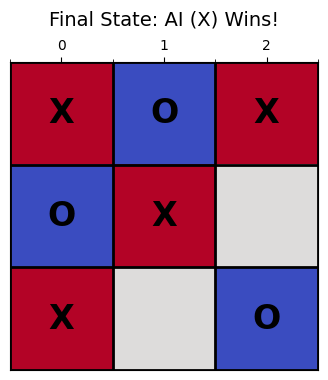

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def create_board():
    return np.zeros((3, 3), dtype=int)

def evaluate(board):
    # Check rows and columns
    for i in range(3):
        if abs(np.sum(board[i, :])) == 3:
            return np.sign(board[i, 0])
        if abs(np.sum(board[:, i])) == 3:
            return np.sign(board[0, i])
            
    # Check diagonals
    if abs(board[0, 0] + board[1, 1] + board[2, 2]) == 3:
        return np.sign(board[0, 0])
    if abs(board[0, 2] + board[1, 1] + board[2, 0]) == 3:
        return np.sign(board[0, 2])
        
    # Check for draw
    if not np.any(board == 0):
        return 0
        
    return None

def minimax(board, depth, is_maximizing):
    score = evaluate(board)
    if score is not None:
        return score

    if is_maximizing:
        max_eval = -float('inf')
        for r, c in zip(*np.where(board == 0)):
            board[r, c] = 1  # AI (X)
            eval = minimax(board, depth + 1, False)
            board[r, c] = 0
            max_eval = max(max_eval, eval)
        return max_eval
    else:
        min_eval = float('inf')
        for r, c in zip(*np.where(board == 0)):
            board[r, c] = -1 # Human (O)
            eval = minimax(board, depth + 1, True)
            board[r, c] = 0
            min_eval = min(min_eval, eval)
        return min_eval

def find_best_move(board):
    best_val = -float('inf')
    best_move = None
    
    for r, c in zip(*np.where(board == 0)):
        board[r, c] = 1
        move_val = minimax(board, 0, False)
        board[r, c] = 0
        
        if move_val > best_val:
            best_val = move_val
            best_move = (r, c)
            
    return best_move

def display_console_board(board):
    symbols = {1: 'X', -1: 'O', 0: ' '}
    b = [[symbols[board[r, c]] for c in range(3)] for r in range(3)]
    print(f"\n {b[0][0]} | {b[0][1]} | {b[0][2]} ")
    print("---+---+---")
    print(f" {b[1][0]} | {b[1][1]} | {b[1][2]} ")
    print("---+---+---")
    print(f" {b[2][0]} | {b[2][1]} | {b[2][2]} \n")

def plot_board(board, title="Final Tic-Tac-Toe Board State"):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.matshow(board, cmap="coolwarm", vmin=-1, vmax=1)
    
    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    
    symbols = {1: 'X', -1: 'O', 0: ''}
    for r in range(3):
        for c in range(3):
            ax.text(c, r, symbols[board[r, c]], ha='center', va='center', fontsize=24, fontweight='bold')
            
    plt.title(title, fontsize=14, pad=10)
    plt.show()

if __name__ == "__main__":
    game_board = create_board()
    move_log = []
    turn = 0
    
    print("=== TIC-TAC-TOE: AI (X) vs Human (O) ===")
    print("Coordinates are entered as Row, Col (0, 1, or 2).\n")

    while evaluate(game_board) is None:
        display_console_board(game_board)
        
        if turn % 2 == 0:
            print("AI (X) is thinking...")
            move = find_best_move(game_board)
            if move:
                game_board[move] = 1
                move_log.append({
                    "Turn": turn + 1,
                    "Player": "AI (X)",
                    "Row": move[0],
                    "Col": move[1]
                })
        else:
            while True:
                try:
                    r = int(input("Enter your Row (0-2): "))
                    c = int(input("Enter your Col (0-2): "))
                    if r not in range(3) or c not in range(3):
                        print("Invalid range! Please enter 0, 1, or 2.")
                    elif game_board[r, c] != 0:
                        print("Position already occupied! Try again.")
                    else:
                        game_board[r, c] = -1
                        move_log.append({
                            "Turn": turn + 1,
                            "Player": "Human (O)",
                            "Row": r,
                            "Col": c
                        })
                        break
                except ValueError:
                    print("Invalid input. Please enter numbers only.")
        turn += 1

    # End game output
    display_console_board(game_board)
    final_eval = evaluate(game_board)
    if final_eval == 1:
        outcome = "AI (X) Wins!"
    elif final_eval == -1:
        outcome = "Human (O) Wins!"
    else:
        outcome = "Draw Match!"
    
    print(f"*** Game Over: {outcome} ***\n")

    # Pandas History DataFrame
    df_moves = pd.DataFrame(move_log)
    print("--- Game Move History Log ---")
    print(df_moves.to_string(index=False))
    
    # Matplotlib Summary Plot
    plot_board(game_board, title=f"Final State: {outcome}")